# Validation of the 137 MHz MWA Average Embedded Element Model

This notebook validates the packaged `mwa_jaxbeam` 137 MHz Average Embedded Element (AEE) beam model. The validation proceeds from basic integrity checks of the packaged runtime data, through verification of the internal interpolation and beam-model implementation, before comparing the final beam response against an independent reference implementation.

The objective is to ensure that the packaged model is internally consistent, numerically stable, and scientifically equivalent to the original MWA beam model.

In [1]:
from pathlib import Path

import cmasher as cmr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap as LSC
from pyuvdata import UVBeam
import jax.numpy as jnp
import healpy as hp
import numpy as np

from mwa_jaxbeam import (
    AZIMUTH_RAD,
    DIPOLE_POSITIONS_ENU_M,
    ELEMENT_JONES,
    FREQUENCY_HZ,
    N_DIPOLES,
    N_FEEDS,
    N_PORTS,
    WAVENUMBER_RAD_PER_M,
    ZA_RAD,
    Z_TOTAL_OHM,
    direction_enu,
    element_jones,
    port_currents,
    array_factor,
    jones,
    coherency,
    power,
)

prd = LSC.from_list("pride", cmr.pride(np.linspace(0.1, 0.8, 256)))
prd.set_under("white")

## 1. Packaged Runtime Data

Before validating the beam model itself, we first verify that the packaged runtime data are internally consistent. These checks ensure that the archived arrays have the expected dimensions, data types, coordinate ordering, and numerical validity before they are used by the runtime implementation.

In [2]:
print(f"Frequency:        {FREQUENCY_HZ / 1e6:.3f} MHz")
print(f"Feeds:            {N_FEEDS}")
print(f"Dipoles:          {N_DIPOLES}")
print(f"Ports:            {N_PORTS}")
print()

print(f"Element Jones:    {ELEMENT_JONES.shape} ({ELEMENT_JONES.dtype})")
print(f"Z Total:          {Z_TOTAL_OHM.shape} ({Z_TOTAL_OHM.dtype})")
print(
    f"Dipole Positions: {DIPOLE_POSITIONS_ENU_M.shape} ({DIPOLE_POSITIONS_ENU_M.dtype})"
)
print(f"Azimuth Grid:     {AZIMUTH_RAD.shape} ({AZIMUTH_RAD.dtype})")
print(f"Zenith Grid:      {ZA_RAD.shape} ({ZA_RAD.dtype})")

Frequency:        137.000 MHz
Feeds:            2
Dipoles:          16
Ports:            32

Element Jones:    (2, 2, 31, 120) (complex64)
Z Total:          (32, 32) (complex64)
Dipole Positions: (16, 3) (float32)
Azimuth Grid:     (120,) (float32)
Zenith Grid:      (31,) (float32)


In [3]:
# Convert to NumPy for validation
az = np.asarray(AZIMUTH_RAD)
za = np.asarray(ZA_RAD)
jones_test = np.asarray(ELEMENT_JONES)
z_total = np.asarray(Z_TOTAL_OHM)
positions = np.asarray(DIPOLE_POSITIONS_ENU_M)

In [4]:
# Array shapes
assert jones_test.shape == (N_FEEDS, N_FEEDS, za.size, az.size)
assert z_total.shape == (N_PORTS, N_PORTS)
assert positions.shape == (N_DIPOLES, 3)

# Dtypes
assert jones_test.dtype == np.complex64
assert z_total.dtype == np.complex64
assert positions.dtype == np.float32
assert az.dtype == np.float32
assert za.dtype == np.float32

# Finite values
assert np.all(np.isfinite(jones_test))
assert np.all(np.isfinite(z_total))
assert np.all(np.isfinite(positions))
assert np.all(np.isfinite(az))
assert np.all(np.isfinite(za))

# Coordinate ordering
assert np.all(np.diff(az) > 0)
assert np.all(np.diff(za) > 0)

# Coordinate ranges
assert np.isclose(az[0], 0.0)
assert np.isclose(np.rad2deg(az[-1]), 357.0)
assert np.isclose(za[0], 0.0)
assert np.isclose(np.rad2deg(za[-1]), 90.0)

# 16 dipoles in a horizontal plane
assert np.allclose(positions[:, 2], positions[0, 2])

# 4 × 4 grid
assert np.unique(positions[:, 0]).size == 4
assert np.unique(positions[:, 1]).size == 4

# 1.1 m spacing
assert np.allclose(np.diff(np.unique(positions[:, 0])), 1.1)
assert np.allclose(np.diff(np.unique(positions[:, 1])), 1.1)

print("Runtime archive validation passed.")

Runtime archive validation passed.


## 2. Coordinate Convention

The beam model uses an East–North–Up Cartesian coordinate system, with azimuth measured eastward from North. We verify that `direction_enu` maps several known azimuth and zenith-angle combinations onto the expected unit vectors.

In [5]:
test_az_deg = np.array(
    [
        0.0,  # North
        90.0,  # East
        180.0,  # South
        270.0,  # West
        0.0,  # Zenith
    ],
)

test_za_deg = np.array(
    [
        90.0,
        90.0,
        90.0,
        90.0,
        0.0,
    ],
)

expected_directions = np.array(
    [
        [0.0, 1.0, 0.0],  # North
        [1.0, 0.0, 0.0],  # East
        [0.0, -1.0, 0.0],  # South
        [-1.0, 0.0, 0.0],  # West
        [0.0, 0.0, 1.0],  # Up
    ],
    dtype=np.float32,
)

directions = np.asarray(
    direction_enu(
        az_rad=np.deg2rad(test_az_deg),
        za_rad=np.deg2rad(test_za_deg),
    )
)

np.testing.assert_allclose(
    directions,
    expected_directions,
    atol=1e-6,
)

print("Cardinal-direction convention passed.")

Cardinal-direction convention passed.


In [6]:
az_test = np.deg2rad(
    np.array([13.0, 71.0, 145.0, 231.0, 319.0]),
)

za_test = np.deg2rad(
    np.array([5.0, 24.0, 47.0, 68.0, 89.0]),
)

directions = np.asarray(
    direction_enu(
        az_rad=az_test,
        za_rad=za_test,
    )
)

norms = np.linalg.norm(directions, axis=-1)

assert directions.shape == (az_test.size, 3)

np.testing.assert_allclose(
    norms,
    1.0,
    atol=1e-6,
)

print("Direction vectors are unit-normalised.")

Direction vectors are unit-normalised.


In [7]:
cardinal_directions = np.asarray(
    direction_enu(
        az_rad=np.deg2rad(test_az_deg),
        za_rad=np.deg2rad(test_za_deg),
    )
)

for az_deg, za_deg, direction in zip(
    test_az_deg,
    test_za_deg,
    cardinal_directions,
):
    print(f"az={az_deg:6.1f}°, za={za_deg:5.1f}°  ->  ENU={direction}")

az=   0.0°, za= 90.0°  ->  ENU=[ 0.000000e+00  1.000000e+00 -4.371139e-08]
az=  90.0°, za= 90.0°  ->  ENU=[ 1.000000e+00 -4.371139e-08 -4.371139e-08]
az= 180.0°, za= 90.0°  ->  ENU=[-8.742278e-08 -1.000000e+00 -4.371139e-08]
az= 270.0°, za= 90.0°  ->  ENU=[-1.0000000e+00  1.1924881e-08 -4.3711388e-08]
az=   0.0°, za=  0.0°  ->  ENU=[0. 0. 1.]


## 3. Element-Jones Interpolation

The packaged archive stores the complex Jones response of the average embedded element on a regular azimuth–zenith-angle grid. We verify that `element_jones` reproduces the archived values exactly at grid nodes, correctly interpolates between adjacent samples, supports broadcasted coordinate arrays, and treats azimuth as a periodic coordinate.

#### 3.1 Reproduction at grid nodes

Evaluate the interpolation routine across the complete archived coordinate grid:

In [8]:
az_grid, za_grid = jnp.meshgrid(
    AZIMUTH_RAD,
    ZA_RAD,
    indexing="xy",
)

interpolated_jones = np.asarray(
    element_jones(
        az_rad=az_grid,
        za_rad=za_grid,
    )
)

stored_jones = np.asarray(ELEMENT_JONES)

print(f"Interpolated shape: {interpolated_jones.shape}")
print(f"Stored shape:       {stored_jones.shape}")

Interpolated shape: (2, 2, 31, 120)
Stored shape:       (2, 2, 31, 120)


In [9]:
assert interpolated_jones.shape == stored_jones.shape

np.testing.assert_allclose(
    interpolated_jones,
    stored_jones,
    rtol=1e-6,
    atol=1e-6,
)

print("Element Jones values are reproduced at every grid node.")

Element Jones values are reproduced at every grid node.


#### 3.2 Scalar-coordinate evaluation

Check that evaluating one direction returns the corresponding archived $2\times2$ Jones matrix:

In [10]:
za_index = 10
az_index = 20

interpolated_scalar = np.asarray(
    element_jones(
        az_rad=AZIMUTH_RAD[az_index],
        za_rad=ZA_RAD[za_index],
    )
)

stored_scalar = stored_jones[
    :,
    :,
    za_index,
    az_index,
]

assert interpolated_scalar.shape == (N_FEEDS, N_FEEDS)

np.testing.assert_allclose(
    interpolated_scalar,
    stored_scalar,
    rtol=1e-6,
    atol=1e-6,
)

print("Scalar element-Jones evaluation passed.")

Scalar element-Jones evaluation passed.


#### 3.3 Interpolation between grid nodes

At the midpoint of a grid cell, bilinear interpolation should equal the mean of its four corners:

In [11]:
za_index = 10
az_index = 20

za_mid = 0.5 * (ZA_RAD[za_index] + ZA_RAD[za_index + 1])

az_mid = 0.5 * (AZIMUTH_RAD[az_index] + AZIMUTH_RAD[az_index + 1])

interpolated_midpoint = np.asarray(
    element_jones(
        az_rad=az_mid,
        za_rad=za_mid,
    )
)

expected_midpoint = 0.25 * (
    stored_jones[:, :, za_index, az_index]
    + stored_jones[:, :, za_index + 1, az_index]
    + stored_jones[:, :, za_index, az_index + 1]
    + stored_jones[:, :, za_index + 1, az_index + 1]
)

np.testing.assert_allclose(
    interpolated_midpoint,
    expected_midpoint,
    rtol=1e-5,
    atol=1e-6,
)

print("Bilinear midpoint interpolation passed.")

Bilinear midpoint interpolation passed.


#### 3.4 Periodic azimuth wrapping

Azimuths that differ by $2\pi$ should produce the same response:

In [12]:
test_za = np.deg2rad(36.0)

jones_zero = np.asarray(
    element_jones(
        az_rad=0.0,
        za_rad=test_za,
    )
)

jones_two_pi = np.asarray(
    element_jones(
        az_rad=2.0 * np.pi,
        za_rad=test_za,
    )
)

np.testing.assert_allclose(
    jones_zero,
    jones_two_pi,
    rtol=1e-6,
    atol=1e-6,
)

print("Azimuth wraps consistently from 2π to 0.")

Azimuth wraps consistently from 2π to 0.


In [13]:
jones_negative = np.asarray(
    element_jones(
        az_rad=np.deg2rad(-3.0),
        za_rad=test_za,
    )
)

jones_positive = np.asarray(
    element_jones(
        az_rad=np.deg2rad(357.0),
        za_rad=test_za,
    )
)

np.testing.assert_allclose(
    jones_negative,
    jones_positive,
    rtol=1e-6,
    atol=1e-6,
)

print("Negative azimuths wrap consistently.")

Negative azimuths wrap consistently.


## 4. Excitations and Port Currents

The MWA tile contains 16 dual-polarised dipoles, corresponding to 32 mutually coupled ports. For each excitation feed, `port_currents` solves the coupled impedance system and returns the currents induced in both sets of dipole ports. The output axes are ordered as: $(\text{excitation feed},\ \text{current feed},\ \text{dipole}),$ giving an output shape of `(2, 2, 16)`. We verify the accepted excitation representations, the impedance-system solution, linearity, and input validation.

#### 4.1 Accepted excitation Representations

Excitations may be supplied as a scalar, a length-16 per-dipole array, or a `(2, 16)` feed–dipole array. Uniform unit excitations should therefore produce identical current solutions in all three cases.

In [14]:
scalar_excitation = 1.0

dipole_excitation = np.ones(
    N_DIPOLES,
    dtype=np.complex64,
)

feed_dipole_excitation = np.ones(
    (N_FEEDS, N_DIPOLES),
    dtype=np.complex64,
)

currents_scalar = np.asarray(
    port_currents(
        excitations=scalar_excitation,
    )
)

currents_dipole = np.asarray(
    port_currents(
        excitations=dipole_excitation,
    )
)

currents_feed_dipole = np.asarray(
    port_currents(
        excitations=feed_dipole_excitation,
    )
)

print(f"Scalar excitation:      {currents_scalar.shape}")
print(f"Dipole excitation:      {currents_dipole.shape}")
print(f"Feed–dipole excitation: {currents_feed_dipole.shape}")

Scalar excitation:      (2, 2, 16)
Dipole excitation:      (2, 2, 16)
Feed–dipole excitation: (2, 2, 16)


In [15]:
expected_shape = (
    N_FEEDS,
    N_FEEDS,
    N_DIPOLES,
)

assert currents_scalar.shape == expected_shape
assert currents_dipole.shape == expected_shape
assert currents_feed_dipole.shape == expected_shape

assert currents_scalar.dtype == np.complex64
assert currents_dipole.dtype == np.complex64
assert currents_feed_dipole.dtype == np.complex64

np.testing.assert_allclose(
    currents_scalar,
    currents_dipole,
    rtol=1e-6,
    atol=1e-6,
)

np.testing.assert_allclose(
    currents_scalar,
    currents_feed_dipole,
    rtol=1e-6,
    atol=1e-6,
)

print("Accepted excitation representations are equivalent.")

Accepted excitation representations are equivalent.


#### 4.2 Output-axis Interpretation

For a given excitation feed, the corresponding output slice has shape `(2, 16)` and contains the currents induced in both sets of dipole ports. The diagonal feed component is the directly driven response, while the off-diagonal component arises from mutual coupling between orthogonal ports.

In [16]:
x_excitation_currents = currents_scalar[0]
y_excitation_currents = currents_scalar[1]

assert x_excitation_currents.shape == (
    N_FEEDS,
    N_DIPOLES,
)
assert y_excitation_currents.shape == (
    N_FEEDS,
    N_DIPOLES,
)

assert np.all(np.isfinite(x_excitation_currents))
assert np.all(np.isfinite(y_excitation_currents))

print(
    f"X excitation, X-port maximum current: {np.max(np.abs(currents_scalar[0, 0])):.6e}"
)
print(
    f"X excitation, Y-port maximum current: {np.max(np.abs(currents_scalar[0, 1])):.6e}"
)
print(
    f"Y excitation, X-port maximum current: {np.max(np.abs(currents_scalar[1, 0])):.6e}"
)
print(
    f"Y excitation, Y-port maximum current: {np.max(np.abs(currents_scalar[1, 1])):.6e}"
)

X excitation, X-port maximum current: 1.097493e-03
X excitation, Y-port maximum current: 3.385457e-06
Y excitation, X-port maximum current: 3.385014e-06
Y excitation, Y-port maximum current: 1.097488e-03


#### 4.3 Coupled Impedance-system Verification

For each independently driven feed, the solved currents should satisfy $\mathbf{Z}_{\mathrm{total}}\mathbf{I}=\mathbf{V}.$

The excitation voltage is applied only to the ports belonging to the selected excitation feed.

- axis 0: port polarization
- axis 1: driven tile feed
- axis 2: dipole

In [17]:
excitation = np.ones(
    (N_FEEDS, N_DIPOLES),
    dtype=np.complex64,
)

currents = np.asarray(
    port_currents(
        excitations=excitation,
    )
)

z_total = np.asarray(Z_TOTAL_OHM)

for driven_feed in range(N_FEEDS):
    voltage = np.zeros(
        (N_FEEDS, N_DIPOLES),
        dtype=np.complex64,
    )
    voltage[driven_feed] = excitation[driven_feed]

    voltage_flat = voltage.reshape(N_PORTS)

    # Select both port polarizations for one driven-feed solution.
    current_flat = currents[:, driven_feed, :].reshape(N_PORTS)

    reconstructed_voltage = z_total @ current_flat

    np.testing.assert_allclose(
        reconstructed_voltage,
        voltage_flat,
        rtol=1e-5,
        atol=1e-6,
    )

print(f"Z-total condition number: {np.linalg.cond(z_total):.3e}")
print("Port currents satisfy the coupled impedance system.")

Z-total condition number: 1.073e+00
Port currents satisfy the coupled impedance system.


#### 4.4 Linearity

The coupled impedance solve is linear in the applied excitation voltage. Multiplying every excitation by a complex scalar should therefore multiply every port current by the same scalar.

In [18]:
scale = 2.0 - 0.5j

reference_currents = np.asarray(
    port_currents(
        excitations=1.0,
    )
)

scaled_currents = np.asarray(
    port_currents(
        excitations=scale,
    )
)

np.testing.assert_allclose(
    scaled_currents,
    scale * reference_currents,
    rtol=1e-5,
    atol=1e-6,
)

print("Port-current solution is linear in excitation voltage.")

Port-current solution is linear in excitation voltage.


#### 4.5 Feed-dependent Excitations

A `(2, 16)` excitation array permits independent dipole weights for the X- and Y-feed solutions. We verify that changing the excitation weights for one driven feed changes only the corresponding current solution.

In [19]:
uniform_excitation = np.ones(
    (N_FEEDS, N_DIPOLES),
    dtype=np.complex64,
)

modified_excitation = uniform_excitation.copy()
modified_excitation[0, 0] = 0.0

uniform_currents = np.asarray(
    port_currents(
        excitations=uniform_excitation,
    )
)

modified_currents = np.asarray(
    port_currents(
        excitations=modified_excitation,
    )
)

# Changing an X-feed excitation should alter the X-driven solution.
assert not np.allclose(
    modified_currents[:, 0, :],
    uniform_currents[:, 0, :],
)

# The independently solved Y-driven response should be unchanged.
np.testing.assert_allclose(
    modified_currents[:, 1, :],
    uniform_currents[:, 1, :],
    rtol=1e-6,
    atol=1e-6,
)

print("Feed-dependent excitations affect only the expected driven-feed solution.")

currents = np.asarray(port_currents(excitations=1.0))

print("Max X-port current when X is driven:", np.max(np.abs(currents[0, 0])))
print("Max Y-port current when X is driven:", np.max(np.abs(currents[1, 0])))

Feed-dependent excitations affect only the expected driven-feed solution.
Max X-port current when X is driven: 0.0010974931
Max Y-port current when X is driven: 3.3850142e-06


#### 4.6 Zero Excitation

With no applied excitation voltage, the resulting port currents should also be zero.

In [20]:
zero_currents = np.asarray(
    port_currents(
        excitations=0.0,
    )
)

np.testing.assert_allclose(
    zero_currents,
    0.0,
    atol=1e-7,
)

print("Zero excitation produces zero port currents.")

Zero excitation produces zero port currents.


#### 4.7 Invalid Excitation Shapes

Only scalar, `(16,)`, and `(2, 16)` excitation inputs are supported. Other array shapes should raise `ValueError`.

In [21]:
invalid_excitations = [
    np.ones(N_PORTS),
    np.ones((N_DIPOLES, N_FEEDS)),
    np.ones((1, N_DIPOLES)),
    np.ones((N_FEEDS, N_DIPOLES, 1)),
]

for excitation in invalid_excitations:
    try:
        port_currents(
            excitations=excitation,
        )
    except ValueError:
        pass
    else:
        raise AssertionError(
            f"Expected ValueError for excitation shape {excitation.shape}."
        )

print("Invalid excitation shapes raise ValueError.")

Invalid excitation shapes raise ValueError.


## 5. Array Factor

The array factor describes the coherent combination of the currents flowing in the 16 tile dipoles. For port polarization $p$, independently driven feed $f$, and sky direction $\hat{\mathbf{s}}$, it is

$$
A_{pf}(\hat{\mathbf{s}})
=
\sum_{n=1}^{16}
I_{pfn}
\exp\left(
i k\,\mathbf{r}_n\cdot\hat{\mathbf{s}}
\right),
$$

where $I_{pfn}$ is the coupled current in dipole $n$, $\mathbf{r}_n$ is its ENU position, and $k$ is the wavenumber$
We validate the output dimensions, coordinate broadcasting, zenith response, geometric phase calculation, excitation linearity, and zero-excitation behaviour.

#### 5.1 Output Shape and Broadcasting

The first two output axes represent the port polarization and independently driven feed, respectively. The remaining axes should match the broadcast shape of the input azimuth and zenith-angle coordinates.

In [22]:
# Scalar direction
factor_scalar = np.asarray(
    array_factor(
        az_rad=0.0,
        za_rad=0.0,
    )
)

assert factor_scalar.shape == (2, 2)
assert np.iscomplexobj(factor_scalar)
assert np.all(np.isfinite(factor_scalar))

print("Scalar output shape:", factor_scalar.shape)

Scalar output shape: (2, 2)


In [23]:
az_rad = np.deg2rad(np.array([0.0, 90.0, 180.0, 270.0]))
za_rad = np.deg2rad(np.array([10.0, 20.0, 30.0, 40.0]))

factor_vector = np.asarray(
    array_factor(
        az_rad=az_rad,
        za_rad=za_rad,
    )
)

assert factor_vector.shape == (2, 2, 4)
assert np.iscomplexobj(factor_vector)
assert np.all(np.isfinite(factor_vector))

print("Vector output shape:", factor_vector.shape)

Vector output shape: (2, 2, 4)


In [24]:
az_rad = np.deg2rad(np.linspace(0.0, 360.0, 13, endpoint=False))
za_rad = np.deg2rad(np.linspace(0.0, 90.0, 7))

factor_grid = np.asarray(
    array_factor(
        az_rad=az_rad[np.newaxis, :],
        za_rad=za_rad[:, np.newaxis],
    )
)

assert factor_grid.shape == (
    2,
    2,
    za_rad.size,
    az_rad.size,
)
assert np.iscomplexobj(factor_grid)
assert np.all(np.isfinite(factor_grid))

print("Grid output shape:", factor_grid.shape)

Grid output shape: (2, 2, 7, 13)


In [25]:
for za_index, za_value in enumerate(za_rad):
    for az_index, az_value in enumerate(az_rad):
        factor_single = np.asarray(
            array_factor(
                az_rad=az_value,
                za_rad=za_value,
            )
        )

        np.testing.assert_allclose(
            factor_grid[:, :, za_index, az_index],
            factor_single,
            rtol=1e-6,
            atol=1e-7,
        )

print("Vectorized and scalar evaluations agree.")

Vectorized and scalar evaluations agree.


#### 5.2 Zenith Response

At zenith,

$$
\hat{\mathbf{s}}=(0,0,1).
$$

All dipoles lie in the horizontal plane, so their vertical coordinates are zero and

$$
\mathbf{r}_n\cdot\hat{\mathbf{s}}=0.
$$

Every geometric phase factor is therefore unity:

$$
\exp\left(
ik\,\mathbf{r}_n\cdot\hat{\mathbf{s}}
\right)=1.
$$

The array factor at zenith should consequently equal the sum of the coupled currents over all 16 dipoles:

$$
A_{pf}(0)
=
\sum_{n=1}^{16} I_{pfn}.
$$

In [26]:
excitations = np.ones(
    (2, 16),
    dtype=np.complex64,
)

currents = np.asarray(
    port_currents(
        excitations=excitations,
    )
)

factor_zenith = np.asarray(
    array_factor(
        az_rad=0.0,
        za_rad=0.0,
        excitations=excitations,
    )
)

expected_zenith = np.sum(
    currents,
    axis=-1,
)

np.testing.assert_allclose(
    factor_zenith,
    expected_zenith,
    rtol=1e-6,
    atol=1e-7,
)

print("The zenith array factor equals the sum of the coupled currents.")

The zenith array factor equals the sum of the coupled currents.


In [27]:
azimuths_rad = np.deg2rad(np.array([0.0, 45.0, 90.0, 180.0, 270.0, 359.0]))

factor_zenith_azimuths = np.asarray(
    array_factor(
        az_rad=azimuths_rad,
        za_rad=0.0,
        excitations=excitations,
    )
)

expected = np.broadcast_to(
    expected_zenith[:, :, np.newaxis],
    factor_zenith_azimuths.shape,
)

np.testing.assert_allclose(
    factor_zenith_azimuths,
    expected,
    rtol=1e-6,
    atol=1e-7,
)

print("The zenith response is independent of azimuth.")

The zenith response is independent of azimuth.


#### 5.3 Independent Geometric-Phase Reconstruction

We independently reconstruct the array factor from the dipole positions and coupled currents, without using `array_factor()` internally. Agreement verifies the geometric path calculation, phase convention, and coherent summation over the 16 dipoles.

In [28]:
az_rad = np.deg2rad(63.0)
za_rad = np.deg2rad(37.0)

excitations = np.ones(
    (2, 16),
    dtype=np.complex64,
)

currents = np.asarray(
    port_currents(
        excitations=excitations,
    )
)

direction = np.asarray(
    direction_enu(
        az_rad=az_rad,
        za_rad=za_rad,
    )
)

geometric_path_m = np.sum(
    np.asarray(DIPOLE_POSITIONS_ENU_M) * direction,
    axis=-1,
)

geometric_phase = np.exp(1j * WAVENUMBER_RAD_PER_M * geometric_path_m)

expected_factor = np.sum(
    currents * geometric_phase[np.newaxis, np.newaxis, :],
    axis=-1,
)

factor = np.asarray(
    array_factor(
        az_rad=az_rad,
        za_rad=za_rad,
        excitations=excitations,
    )
)

np.testing.assert_allclose(
    factor,
    expected_factor,
    rtol=1e-6,
    atol=1e-7,
)

print("The scalar array factor agrees with an independent reconstruction.")

The scalar array factor agrees with an independent reconstruction.


In [29]:
np.testing.assert_allclose(
    np.abs(geometric_phase),
    1.0,
    rtol=1e-6,
    atol=1e-7,
)

print("All geometric phase factors have unit magnitude.")

All geometric phase factors have unit magnitude.


In [30]:
az_rad = np.deg2rad(np.array([0.0, 45.0, 120.0, 270.0]))
za_rad = np.deg2rad(np.array([0.0, 20.0, 50.0]))

az_grid = az_rad[np.newaxis, :]
za_grid = za_rad[:, np.newaxis]

direction = np.asarray(
    direction_enu(
        az_rad=az_grid,
        za_rad=za_grid,
    )
)

# direction:            (Nza, Naz, 3)
# positions:            (16, 3)
# geometric_path_m:     (Nza, Naz, 16)
geometric_path_m = np.sum(
    direction[..., np.newaxis, :] * np.asarray(DIPOLE_POSITIONS_ENU_M),
    axis=-1,
)

geometric_phase = np.exp(1j * WAVENUMBER_RAD_PER_M * geometric_path_m)

# currents:             (2, 2, 16)
# geometric_phase:      (Nza, Naz, 16)
# expected_factor:      (2, 2, Nza, Naz)
expected_factor = np.sum(
    currents[:, :, np.newaxis, np.newaxis, :]
    * geometric_phase[np.newaxis, np.newaxis, ...],
    axis=-1,
)

factor = np.asarray(
    array_factor(
        az_rad=az_grid,
        za_rad=za_grid,
        excitations=excitations,
    )
)

np.testing.assert_allclose(
    factor,
    expected_factor,
    rtol=1e-6,
    atol=1e-7,
)

print("The gridded array factor agrees with an independent reconstruction.")

The gridded array factor agrees with an independent reconstruction.


#### 5.4 Complex Linearity

The impedance solve and coherent array-factor sum are both linear in the applied excitation voltage. Multiplying every excitation by a complex scalar should therefore multiply the complete array-factor matrix by the same scalar.

In [31]:
az_rad = np.deg2rad(np.array([15.0, 90.0, 210.0]))
za_rad = np.deg2rad(np.array([10.0, 35.0, 60.0]))

scale = 2.0 - 0.5j

reference_factor = np.asarray(
    array_factor(
        az_rad=az_rad,
        za_rad=za_rad,
        excitations=1.0,
    )
)

scaled_factor = np.asarray(
    array_factor(
        az_rad=az_rad,
        za_rad=za_rad,
        excitations=scale,
    )
)

np.testing.assert_allclose(
    scaled_factor,
    scale * reference_factor,
    rtol=1e-5,
    atol=1e-6,
)

print("The array factor is linear in the applied excitation voltage.")

The array factor is linear in the applied excitation voltage.


#### 5.5 Zero Excitation

With no applied excitation voltage, all coupled currents vanish and the array factor should be zero in every direction.

In [32]:
az_rad = np.deg2rad(np.linspace(0.0, 360.0, 13, endpoint=False))
za_rad = np.deg2rad(np.linspace(0.0, 90.0, 7))

zero_factor = np.asarray(
    array_factor(
        az_rad=az_rad[np.newaxis, :],
        za_rad=za_rad[:, np.newaxis],
        excitations=0.0,
    )
)

np.testing.assert_allclose(
    zero_factor,
    0.0,
    atol=1e-7,
)

print("Zero excitation produces a zero array factor.")

Zero excitation produces a zero array factor.


#### 5.6 Visualize the array-factor pattern

This is an exploratory physics check rather than a strict unit test. Plot the co-polar array-factor power over the visible hemisphere: $P_{\rm AF} = |A_{pf}|^2.$

For example, start with the X-port response when the X feed is driven:

In [33]:
az_rad = np.deg2rad(np.linspace(0.0, 360.0, 361))
za_rad = np.deg2rad(np.linspace(0.0, 90.0, 181))

factor = np.asarray(
    array_factor(
        az_rad=az_rad[np.newaxis, :],
        za_rad=za_rad[:, np.newaxis],
        excitations=1.0,
    )
)

power_xx = np.abs(factor[0, 0]) ** 2
power_xx_db = 10.0 * np.log10(power_xx / np.nanmax(power_xx))

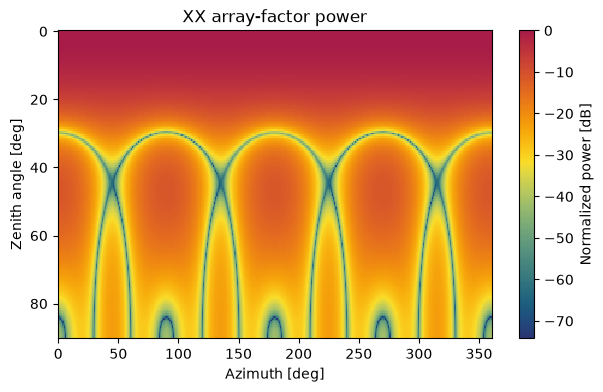

In [34]:
fig, ax = plt.subplots(figsize=(7, 4))

image = ax.pcolormesh(
    np.rad2deg(az_rad),
    np.rad2deg(za_rad),
    power_xx_db,
    shading="auto",
    cmap=prd,
)

ax.set_xlabel("Azimuth [deg]")
ax.set_ylabel("Zenith angle [deg]")
ax.set_title("XX array-factor power")
ax.invert_yaxis()

fig.colorbar(
    image,
    ax=ax,
    label="Normalized power [dB]",
)

plt.show()

#### 5.7 HEALPix Visualization

We evaluate the co-polar array-factor power at the centre of every HEALPix pixel and display the visible hemisphere in a local ENU coordinate system.

In [35]:
nside = 32
npix = hp.nside2npix(nside)

# HEALPix angular coordinates:
#
# theta = colatitude
# phi   = longitude measured from +x toward +y
theta_rad, phi_rad = hp.pix2ang(
    nside,
    np.arange(npix),
)

# For the ENU Cartesian convention:
#
# x = East
# y = North
# z = Up
#
# direction_enu() uses azimuth measured eastward from North, so
#
# az = pi/2 - phi
# za = theta
az_rad = np.mod(
    0.5 * np.pi - phi_rad,
    2.0 * np.pi,
)
za_rad = theta_rad

factor_hpx = np.asarray(
    array_factor(
        az_rad=az_rad,
        za_rad=za_rad,
        excitations=1.0,
    )
)

power_xx = np.abs(factor_hpx[0, 0]) ** 2

# Hide the lower hemisphere.
visible = za_rad <= 0.5 * np.pi

power_xx_db = np.full(
    npix,
    hp.UNSEEN,
    dtype=float,
)

power_xx_db[visible] = 10.0 * np.log10(power_xx[visible] / np.nanmax(power_xx[visible]))

power_xx_db[visible] = np.maximum(
    power_xx_db[visible],
    -40.0,
)

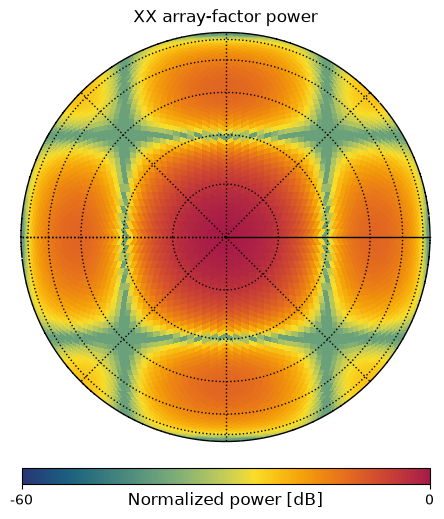

In [36]:
hp.orthview(
    power_xx_db,
    rot=(0, 90, -90),
    half_sky=True,
    flip="geo",
    min=-60.0,
    max=0.0,
    title="XX array-factor power",
    unit="Normalized power [dB]",
    badcolor="whitesmoke",
    cmap=prd,
)

hp.graticule(
    dpar=15,
    dmer=45,
)

#### 5.8 Symmetry checks

After looking at the plots, test the expected tile symmetries.

For a centred square array with symmetric excitation, the co-polar power should approximately satisfy

$$
|A(0^\circ,\mathrm{ZA})|^2
=
|A(180^\circ,\mathrm{ZA})|^2
$$

and

$$
|A(90^\circ,\mathrm{ZA})|^2
=
|A(270^\circ,\mathrm{ZA})|^2.
$$

I would compare power rather than complex voltage because opposite directions can differ by phase while still having identical power.

In [37]:
za_rad = np.deg2rad(np.linspace(0.0, 90.0, 181))

factor_north = np.asarray(
    array_factor(
        az_rad=np.deg2rad(0.0),
        za_rad=za_rad,
        excitations=1.0,
    )
)

factor_south = np.asarray(
    array_factor(
        az_rad=np.deg2rad(180.0),
        za_rad=za_rad,
        excitations=1.0,
    )
)

power_north = np.abs(factor_north) ** 2
power_south = np.abs(factor_south) ** 2

np.testing.assert_allclose(
    power_north,
    power_south,
    rtol=1e-5,
    atol=1e-7,
)

residual = power_north - power_south

print("Maximum north–south power difference:", np.max(np.abs(residual)))
print("North–south array-factor powers agree.")

Maximum north–south power difference: 1.7462298e-10
North–south array-factor powers agree.


## 6. Tile Jones Matrix

The full tile Jones matrix combines the averaged embedded-element response with the coupled array factor:

$$
J^{\mathrm{tile}}_{sf}(\hat{\mathbf{s}})
=
\sum_{p}
J^{\mathrm{element}}_{sp}(\hat{\mathbf{s}})
A_{pf}(\hat{\mathbf{s}}),
$$

where $s$ indexes the sky-vector components $(\phi,\theta)$, $p$ indexes the physical port polarizations $(X,Y)$, and $f$ indexes the independently driven tile feeds $(X,Y)$.

We validate the output shape, broadcasting behaviour, matrix contraction, zenith response, excitation linearity, and zero-excitation behaviour.

#### 6.1 Output Shape and Broadcasting

The first output axis contains the sky-vector components $(\phi,\theta)$, and the second contains the independently driven tile feeds $(X,Y)$. Any remaining axes should match the broadcast shape of the input coordinates.

In [38]:
tile_jones_scalar = np.asarray(
    jones(
        az_rad=0.0,
        za_rad=0.0,
    )
)

assert tile_jones_scalar.shape == (2, 2)
assert np.iscomplexobj(tile_jones_scalar)
assert np.all(np.isfinite(tile_jones_scalar))

print("Scalar Jones shape:", tile_jones_scalar.shape)

Scalar Jones shape: (2, 2)


In [39]:
az_rad = np.deg2rad(np.array([0.0, 90.0, 180.0, 270.0]))
za_rad = np.deg2rad(np.array([10.0, 20.0, 30.0, 40.0]))

tile_jones_vector = np.asarray(
    jones(
        az_rad=az_rad,
        za_rad=za_rad,
    )
)

assert tile_jones_vector.shape == (2, 2, 4)
assert np.iscomplexobj(tile_jones_vector)
assert np.all(np.isfinite(tile_jones_vector))

print("Vector Jones shape:", tile_jones_vector.shape)

Vector Jones shape: (2, 2, 4)


In [40]:
az_rad = np.deg2rad(np.linspace(0.0, 360.0, 13, endpoint=False))
za_rad = np.deg2rad(np.linspace(0.0, 90.0, 7))

tile_jones_grid = np.asarray(
    jones(
        az_rad=az_rad[np.newaxis, :],
        za_rad=za_rad[:, np.newaxis],
    )
)

assert tile_jones_grid.shape == (
    2,
    2,
    za_rad.size,
    az_rad.size,
)
assert np.iscomplexobj(tile_jones_grid)
assert np.all(np.isfinite(tile_jones_grid))

print("Grid Jones shape:", tile_jones_grid.shape)

Grid Jones shape: (2, 2, 7, 13)


In [41]:
for za_index, za_value in enumerate(za_rad):
    for az_index, az_value in enumerate(az_rad):
        tile_jones_single = np.asarray(
            jones(
                az_rad=az_value,
                za_rad=za_value,
            )
        )

        np.testing.assert_allclose(
            tile_jones_grid[:, :, za_index, az_index],
            tile_jones_single,
            rtol=1e-6,
            atol=1e-7,
        )

print("Vectorized and scalar Jones evaluations agree.")

Vectorized and scalar Jones evaluations agree.


#### 6.2 Independent Matrix Reconstruction

We independently reconstruct the tile Jones matrix from the element Jones matrix and coupled array-factor matrix. Agreement verifies the contraction over the port-polarization axis and the associated axis ordering.

In [42]:
az_rad = np.deg2rad(63.0)
za_rad = np.deg2rad(37.0)

excitations = np.ones(
    (2, 16),
    dtype=np.complex64,
)

element = np.asarray(
    element_jones(
        az_rad=az_rad,
        za_rad=za_rad,
    )
)

factor = np.asarray(
    array_factor(
        az_rad=az_rad,
        za_rad=za_rad,
        excitations=excitations,
    )
)

expected_tile_jones = element @ factor

tile_jones = np.asarray(
    jones(
        az_rad=az_rad,
        za_rad=za_rad,
        excitations=excitations,
    )
)

np.testing.assert_allclose(
    tile_jones,
    expected_tile_jones,
    rtol=1e-6,
    atol=1e-7,
)

print("The scalar tile Jones matrix agrees with an independent reconstruction.")

The scalar tile Jones matrix agrees with an independent reconstruction.


In [43]:
az_rad = np.deg2rad(np.array([0.0, 45.0, 120.0, 270.0]))
za_rad = np.deg2rad(np.array([0.0, 20.0, 50.0]))

az_grid = az_rad[np.newaxis, :]
za_grid = za_rad[:, np.newaxis]

element = np.asarray(
    element_jones(
        az_rad=az_grid,
        za_rad=za_grid,
    )
)

factor = np.asarray(
    array_factor(
        az_rad=az_grid,
        za_rad=za_grid,
        excitations=excitations,
    )
)

element_matrix = np.moveaxis(
    element,
    (0, 1),
    (-2, -1),
)

factor_matrix = np.moveaxis(
    factor,
    (0, 1),
    (-2, -1),
)

expected_tile_jones = np.moveaxis(
    element_matrix @ factor_matrix,
    (-2, -1),
    (0, 1),
)

tile_jones = np.asarray(
    jones(
        az_rad=az_grid,
        za_rad=za_grid,
        excitations=excitations,
    )
)

np.testing.assert_allclose(
    tile_jones,
    expected_tile_jones,
    rtol=1e-6,
    atol=1e-7,
)

print("The gridded tile Jones matrix agrees with an independent reconstruction.")

The gridded tile Jones matrix agrees with an independent reconstruction.


#### 6.3 Zenith Response

At zenith, every geometric phase factor is unity. The full tile Jones matrix should therefore equal the zenith element Jones matrix multiplied by the dipole-summed coupled-current matrix.

In [44]:
excitations = np.ones(
    (2, 16),
    dtype=np.complex64,
)

element_zenith = np.asarray(
    element_jones(
        az_rad=0.0,
        za_rad=0.0,
    )
)

currents = np.asarray(
    port_currents(
        excitations=excitations,
    )
)

summed_currents = np.sum(
    currents,
    axis=-1,
)

expected_zenith = element_zenith @ summed_currents

tile_jones_zenith = np.asarray(
    jones(
        az_rad=0.0,
        za_rad=0.0,
        excitations=excitations,
    )
)

np.testing.assert_allclose(
    tile_jones_zenith,
    expected_zenith,
    rtol=1e-6,
    atol=1e-7,
)

print("The zenith tile Jones matrix matches the analytic reconstruction.")

The zenith tile Jones matrix matches the analytic reconstruction.


#### 6.4 Complex Linearity

Both the coupled-current solve and the subsequent Jones-matrix construction are linear in the applied excitation voltage. Multiplying every excitation by a complex scalar should therefore multiply the complete tile Jones matrix by the same scalar.

In [45]:
az_rad = np.deg2rad(np.array([15.0, 90.0, 210.0]))
za_rad = np.deg2rad(np.array([10.0, 35.0, 60.0]))

scale = 2.0 - 0.5j

reference_jones = np.asarray(
    jones(
        az_rad=az_rad,
        za_rad=za_rad,
        excitations=1.0,
    )
)

scaled_jones = np.asarray(
    jones(
        az_rad=az_rad,
        za_rad=za_rad,
        excitations=scale,
    )
)

np.testing.assert_allclose(
    scaled_jones,
    scale * reference_jones,
    rtol=1e-5,
    atol=1e-6,
)

print("The tile Jones matrix is linear in the applied excitation voltage.")

The tile Jones matrix is linear in the applied excitation voltage.


#### 6.5 Zero Excitation

With no applied excitation voltage, all coupled currents vanish. The resulting tile Jones matrix should therefore be zero in every direction.

In [46]:
az_rad = np.deg2rad(np.linspace(0.0, 360.0, 13, endpoint=False))
za_rad = np.deg2rad(np.linspace(0.0, 90.0, 7))

zero_jones = np.asarray(
    jones(
        az_rad=az_rad[np.newaxis, :],
        za_rad=za_rad[:, np.newaxis],
        excitations=0.0,
    )
)

np.testing.assert_allclose(
    zero_jones,
    0.0,
    atol=1e-7,
)

print("Zero excitation produces a zero tile Jones matrix.")

Zero excitation produces a zero tile Jones matrix.


#### 6.6 Jones-Matrix Visualisation

We evaluate the four complex Jones-matrix components over the visible hemisphere. Because Jones entries are voltage-like quantities, their normalized amplitudes are displayed using

$$
20\log_{10}\left(
\frac{|J_{sf}|}{\max |J|}
\right).
$$

In [47]:
nside = 32
npix = hp.nside2npix(nside)

theta_rad, phi_rad = hp.pix2ang(
    nside,
    np.arange(npix),
)

az_rad = np.mod(
    0.5 * np.pi - phi_rad,
    2.0 * np.pi,
)
za_rad = theta_rad

tile_jones_hpx = np.asarray(
    jones(
        az_rad=az_rad,
        za_rad=za_rad,
        excitations=1.0,
    )
)

visible = za_rad <= 0.5 * np.pi

jones_amplitude = np.abs(tile_jones_hpx)

normalization = np.nanmax(jones_amplitude[:, :, visible])

jones_db = np.full(
    (2, 2, npix),
    hp.UNSEEN,
    dtype=float,
)

for sky_component in range(2):
    for driven_feed in range(2):
        amplitude = jones_amplitude[
            sky_component,
            driven_feed,
        ]

        jones_db[
            sky_component,
            driven_feed,
            visible,
        ] = 20.0 * np.log10(amplitude[visible] / normalization)

        jones_db[
            sky_component,
            driven_feed,
            visible,
        ] = np.maximum(
            jones_db[
                sky_component,
                driven_feed,
                visible,
            ],
            -60.0,
        )

/var/folders/d3/70sqp6554195488sw7mn9_kh0000gn/T/ipykernel_19314/904528957.py:46: RuntimeWarning: divide by zero encountered in log10
  ] = 20.0 * np.log10(amplitude[visible] / normalization)


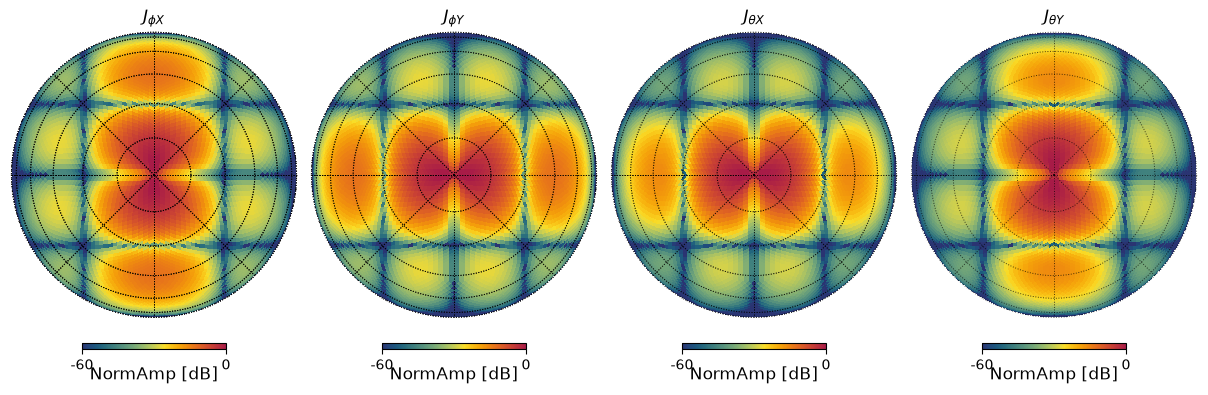

In [48]:
component_labels = [
    [r"$J_{\phi X}$", r"$J_{\phi Y}$"],
    [r"$J_{\theta X}$", r"$J_{\theta Y}$"],
]

fig = plt.figure(figsize=(12, 5))

i = 1
for sky_component in range(2):
    for driven_feed in range(2):
        hp.orthview(
            jones_db[
                sky_component,
                driven_feed,
            ],
            rot=(0, 90, -90),
            half_sky=True,
            fig=fig,
            sub=(1, 4, i),
            flip="geo",
            min=-60.0,
            max=0.0,
            title=component_labels[sky_component][driven_feed],
            unit="\n\nNormAmp [dB]",
            badcolor="whitesmoke",
            cmap=prd,
        )

        hp.graticule(dpar=15, dmer=45, ls=":", lw=0.7, alpha=0.7)

        i += 1

plt.show()

## 7. Coherency Response

For an unpolarized source, the feed coherency response is

$$
\mathbf C(\hat{\mathbf s})
=
\mathbf J^\dagger(\hat{\mathbf s})
\mathbf J(\hat{\mathbf s}),
$$

where $\mathbf J$ is the tile Jones matrix. The resulting $2\times2$ matrix has feed ordering

$$
\mathbf C
=
\begin{pmatrix}
XX & XY\\
YX & YY
\end{pmatrix}.
$$

We validate the matrix construction, Hermitian symmetry, non-negative diagonal terms, normalization, excitation scaling, and zero-excitation behaviour.

#### 7.1 Output shape and independent reconstruction

In [49]:
az_rad = np.deg2rad(np.array([15.0, 90.0, 210.0]))
za_rad = np.deg2rad(np.array([10.0, 35.0, 60.0]))

response = np.asarray(
    coherency(
        az_rad=az_rad,
        za_rad=za_rad,
    )
)

assert response.shape == (2, 2, 3)
assert np.iscomplexobj(response)
assert np.all(np.isfinite(response))

tile_jones = np.asarray(
    jones(
        az_rad=az_rad,
        za_rad=za_rad,
    )
)

jones_matrix = np.moveaxis(
    tile_jones,
    (0, 1),
    (-2, -1),
)

expected_response = np.swapaxes(jones_matrix.conj(), -2, -1) @ jones_matrix

expected_response = np.moveaxis(
    expected_response,
    (-2, -1),
    (0, 1),
)

np.testing.assert_allclose(
    response,
    expected_response,
    rtol=1e-6,
    atol=1e-7,
)

print("The coherency response agrees with J\u2020J.")

The coherency response agrees with J†J.


#### 7.2 Hermitian structure

Because

$$\mathbf C=\mathbf J^\dagger\mathbf J,$$

it must satisfy

$$\mathbf C^\dagger=\mathbf C.$$

Therefore,

$$YX=XY^*$$

and the diagonal terms should be real.

In [50]:
np.testing.assert_allclose(
    response[1, 0],
    response[0, 1].conj(),
    rtol=1e-6,
    atol=1e-7,
)

np.testing.assert_allclose(
    response[0, 0].imag,
    0.0,
    atol=1e-7,
)

np.testing.assert_allclose(
    response[1, 1].imag,
    0.0,
    atol=1e-7,
)

assert np.all(response[0, 0].real >= -1e-7)
assert np.all(response[1, 1].real >= -1e-7)

print("The coherency matrix is Hermitian with non-negative diagonal terms.")

The coherency matrix is Hermitian with non-negative diagonal terms.


In [51]:
response_matrix = np.moveaxis(
    response,
    (0, 1),
    (-2, -1),
)

eigenvalues = np.linalg.eigvalsh(response_matrix)

assert np.all(eigenvalues >= -1e-6)

print("The coherency matrix is positive semidefinite.")

The coherency matrix is positive semidefinite.


#### 8.3 Normalization

With `normalize=True`, the zenith diagonal terms should be unity:

In [52]:
zenith_response = np.asarray(
    coherency(
        az_rad=0.0,
        za_rad=0.0,
        normalize=True,
    )
)

np.testing.assert_allclose(
    zenith_response[0, 0],
    1.0,
    rtol=1e-6,
    atol=1e-7,
)

np.testing.assert_allclose(
    zenith_response[1, 1],
    1.0,
    rtol=1e-6,
    atol=1e-7,
)

print("The normalized zenith feed powers are unity.")

The normalized zenith feed powers are unity.


#### 7.4 Excitation scaling

Since J scales linearly with excitation,

$$J(cV)=cJ(V),$$

the coherency scales as

$$C(cV)=|c|^2 C(V).$$

In [53]:
scale = 2.0 - 0.5j

reference_response = np.asarray(
    coherency(
        az_rad=az_rad,
        za_rad=za_rad,
        excitations=1.0,
    )
)

scaled_response = np.asarray(
    coherency(
        az_rad=az_rad,
        za_rad=za_rad,
        excitations=scale,
    )
)

np.testing.assert_allclose(
    scaled_response,
    np.abs(scale) ** 2 * reference_response,
    rtol=1e-5,
    atol=1e-6,
)

print("The coherency scales with the squared excitation magnitude.")

The coherency scales with the squared excitation magnitude.


#### 7.5 Zero excitation

In [54]:
zero_response = np.asarray(
    coherency(
        az_rad=az_rad,
        za_rad=za_rad,
        excitations=0.0,
    )
)

np.testing.assert_allclose(
    zero_response,
    0.0,
    atol=1e-7,
)

print("Zero excitation produces zero coherency.")

Zero excitation produces zero coherency.


#### 7.6 HEALPix maps

For the plots, I would show:

* $XX$: power in dB
* $YY$: power in dB
* $|XY|$: amplitude in dB
* $\arg(XY)$: phase

Plotting all four complex matrix entries as simple amplitudes would be redundant because $YX=XY^*$, so $|YX|=|XY|$.

In [55]:
nside = 32
npix = hp.nside2npix(nside)

theta_rad, phi_rad = hp.pix2ang(
    nside,
    np.arange(npix),
)

az_rad_hpx = np.mod(
    0.5 * np.pi - phi_rad,
    2.0 * np.pi,
)
za_rad_hpx = theta_rad

response_hpx = np.asarray(
    coherency(
        az_rad=az_rad_hpx,
        za_rad=za_rad_hpx,
        normalize=True,
    )
)

visible = za_rad_hpx <= 0.5 * np.pi

coherency_db = np.full(
    (2, 2, npix),
    hp.UNSEEN,
    dtype=float,
)

for feed_1 in range(2):
    for feed_2 in range(2):
        magnitude = np.abs(response_hpx[feed_1, feed_2])

        coherency_db[
            feed_1,
            feed_2,
            visible,
        ] = 10.0 * np.log10(
            np.maximum(
                magnitude[visible],
                1e-12,
            )
        )

        coherency_db[
            feed_1,
            feed_2,
            visible,
        ] = np.maximum(
            coherency_db[
                feed_1,
                feed_2,
                visible,
            ],
            -60.0,
        )

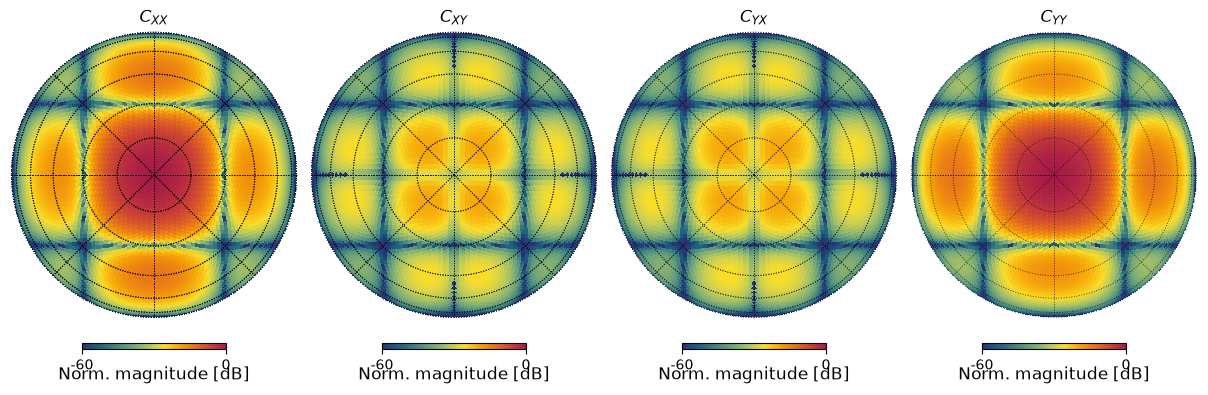

In [56]:
component_labels = [
    [r"$C_{XX}$", r"$C_{XY}$"],
    [r"$C_{YX}$", r"$C_{YY}$"],
]

fig = plt.figure(figsize=(12, 5))

i = 1
for feed_1 in range(2):
    for feed_2 in range(2):
        hp.orthview(
            coherency_db[
                feed_1,
                feed_2,
            ],
            rot=(0, 90, -90),
            half_sky=True,
            fig=fig,
            sub=(1, 4, i),
            flip="geo",
            min=-60.0,
            max=0.0,
            title=component_labels[feed_1][feed_2],
            unit="\n\nNorm. magnitude [dB]",
            badcolor="whitesmoke",
            cmap=prd,
        )

        hp.graticule(
            dpar=15,
            dmer=45,
            ls=":",
            lw=0.7,
            alpha=0.7,
        )

        i += 1

plt.show()

## 8. Final XX and YY Beam Maps

The `power()` convenience function returns the real diagonal terms of the feed coherency matrix,

$$
P_{XX} = C_{XX},
\qquad
P_{YY} = C_{YY}.
$$

We verify this relationship and then display the normalized XX and YY beam-power responses over the visible hemisphere.

In [57]:
nside = 64
npix = hp.nside2npix(nside)

theta_rad, phi_rad = hp.pix2ang(
    nside,
    np.arange(npix),
)

az_rad_hpx = np.mod(
    0.5 * np.pi - phi_rad,
    2.0 * np.pi,
)
za_rad_hpx = theta_rad

power_hpx = np.asarray(
    power(
        az_rad=az_rad_hpx,
        za_rad=za_rad_hpx,
        normalize=True,
    )
)

coherency_hpx = np.asarray(
    coherency(
        az_rad=az_rad_hpx,
        za_rad=za_rad_hpx,
        normalize=True,
    )
)

expected_power = np.stack(
    (
        coherency_hpx[0, 0].real,
        coherency_hpx[1, 1].real,
    ),
    axis=0,
)

np.testing.assert_allclose(
    power_hpx,
    expected_power,
    rtol=1e-6,
    atol=1e-7,
)

print("Power agrees with the diagonal coherency terms.")

Power agrees with the diagonal coherency terms.


In [58]:
visible = za_rad_hpx <= 0.5 * np.pi

power_db = np.full(
    (2, npix),
    hp.UNSEEN,
    dtype=float,
)

for feed in range(2):
    power_db[feed, visible] = 10.0 * np.log10(
        np.maximum(
            power_hpx[feed, visible],
            1e-12,
        )
    )

    power_db[feed, visible] = np.maximum(
        power_db[feed, visible],
        -60.0,
    )

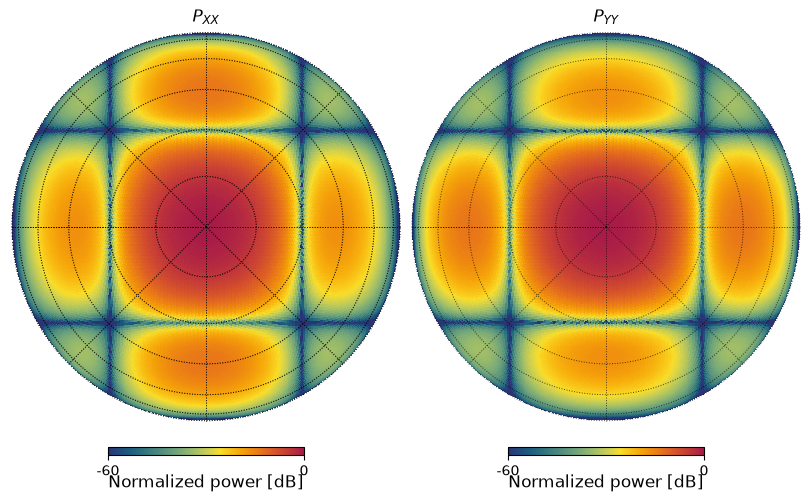

In [59]:
component_labels = [
    r"$P_{XX}$",
    r"$P_{YY}$",
]

fig = plt.figure(figsize=(8, 5))

for feed in range(2):
    hp.orthview(
        power_db[feed],
        rot=(0, 90, -90),
        half_sky=True,
        fig=fig,
        sub=(1, 2, feed + 1),
        flip="geo",
        min=-60.0,
        max=0.0,
        title=component_labels[feed],
        unit="\n\nNormalized power [dB]",
        badcolor="whitesmoke",
        cmap=prd,
    )

    hp.graticule(
        dpar=15,
        dmer=45,
        ls=":",
        lw=0.7,
        alpha=0.7,
    )

plt.show()

The normalized XX and YY maps show the expected orthogonal responses of the two tile feeds. These maps represent the complete model output, combining the archived averaged embedded-element response, mutually coupled port currents, geometric array factor, and full tile Jones matrix.

## 9. Comparison with the pyuvdata AEE Implementation

As an external validation, we compare the normalized XX and YY power
responses against the independent AEE implementation provided by
`pyuvdata`.

Both implementations are evaluated at the same HEALPix pixel centres and
frequency. Our beam model uses azimuth measured from North through East,
whereas the native `UVBeam` convention is measured from East through North.
We therefore convert the azimuth supplied to `pyuvdata` according to

$$
\mathrm{az}_{\mathrm{pyuvdata}}
=
\left(
\frac{\pi}{2}
-
\mathrm{az}_{\mathrm{ours}}
\right)
\bmod 2\pi.
$$

The power residual is defined as

$$
\Delta P =
10\log_{10}P_{\mathrm{JAX}}
-
10\log_{10}P_{\mathrm{pyuvdata}}.
$$

In [60]:
aee_beam = UVBeam()

delays = np.zeros((2, 16), dtype=int)
amplitudes = np.ones((2, 16), dtype=float)

aee_beam.read_mwa_beam(
    "../data/Jmatrix.fits",
    zfile="../data/ZMatrix.fits",
    delays=delays,
    amplitudes=amplitudes,
    include_cross_feed_coupling=True,
)

#### 9.1 Inspect the pyuvdata output

In [61]:
print("Beam type:", aee_beam.beam_type)
print("Coordinate system:", aee_beam.pixel_coordinate_system)
print("Frequency range [MHz]:", aee_beam.freq_array[[0, -1]] / 1e6)
print("Feed array:", aee_beam.feed_array)
print("Polarization array:", aee_beam.polarization_array)
print("Data shape:", aee_beam.data_array.shape)

Beam type: efield
Coordinate system: az_za
Frequency range [MHz]: [ 72.96 239.36]
Feed array: ['x' 'y']
Polarization array: None
Data shape: (2, 2, 63, 31, 121)


#### 9.2 Compare several cardinal directions

In [62]:
freq_hz = 137e6

az_jax = np.deg2rad(
    np.array([0.0, 90.0, 180.0, 270.0])
)
za_rad = np.deg2rad(
    np.full(4, 30.0)
)

# JAX: North -> East
# pyuvdata: East -> North
az_pyuvdata = np.mod(
    np.pi / 2 - az_jax,
    2 * np.pi,
)

In [63]:
freq_hz = 137e6

az_jax = np.deg2rad(
    np.array([0.0, 90.0, 180.0, 270.0])
)
za_rad = np.deg2rad(
    np.full(4, 30.0)
)

# JAX: North -> East
# pyuvdata: East -> North
az_pyuvdata = np.mod(
    np.pi / 2 - az_jax,
    2 * np.pi,
)

In [64]:
pyuv_efield, _ = aee_beam.interp(
    az_array=az_pyuvdata,
    za_array=za_rad,
    freq_array=np.array([freq_hz]),
    return_basis_vector=False,
    check_azza_domain=True,
)

print("Interpolated shape:", pyuv_efield.shape)

assert pyuv_efield.shape == (2, 2, 1, 4)

Interpolated shape: (2, 2, 1, 4)


In [65]:
pyuv_efield = pyuv_efield[:, :, 0, :]

pyuv_power = np.sum(
    np.abs(pyuv_efield) ** 2,
    axis=0,
)

assert pyuv_power.shape == (2, 4)

#### 9.3 Normalize pyuvdata at exact zenith

Use the pyuvdata equivalent of our azimuth $0^\circ$:

In [66]:
zenith_result = aee_beam.interp(
    az_array=np.array([np.pi / 2]),
    za_array=np.array([0.0]),
    freq_array=np.array([freq_hz]),
    return_basis_vector=False,
    check_azza_domain=True,
)

if isinstance(zenith_result, tuple):
    pyuv_zenith_efield = np.asarray(zenith_result[0])
else:
    pyuv_zenith_efield = np.asarray(zenith_result)

pyuv_zenith_power = np.sum(
    np.abs(pyuv_zenith_efield[:, :, 0, 0]) ** 2,
    axis=0,
)

In [67]:
pyuv_zenith_power = np.sum(
    np.abs(pyuv_zenith_efield[:, :, 0, 0]) ** 2,
    axis=0,
)

assert pyuv_zenith_power.shape == (2,)

pyuv_power_norm = (
    pyuv_power
    / pyuv_zenith_power[:, np.newaxis]
)

In [68]:
freq_hz = 137e6

az_jax = np.deg2rad([0, 90, 180, 270])
za_rad = np.deg2rad([30, 30, 30, 30])

# Convert to pyuvdata convention
az_pyuvdata = np.mod(np.pi / 2 - az_jax, 2 * np.pi)

jax_power = np.asarray(
    power(
        az_rad=az_jax,
        za_rad=za_rad,
        normalize=True,
    )
)

print(jax_power.shape)

(2, 4)


In [69]:
directions = ("North", "East", "South", "West")

for feed, label in enumerate(("XX", "YY")):
    print(f"\n{label}")

    for index, direction in enumerate(directions):
        jax_value = jax_power[feed, index]
        pyuv_value = pyuv_power_norm[feed, index]

        residual_db = 10.0 * np.log10(jax_value / pyuv_value)

        print(
            f"{direction:5s}: "
            f"JAX={jax_value:.6f}, "
            f"pyuvdata={pyuv_value:.6f}, "
            f"residual={residual_db:+.4f} dB"
        )


XX
North: JAX=0.000076, pyuvdata=0.000076, residual=-0.0069 dB
East : JAX=0.000094, pyuvdata=0.000094, residual=+0.0045 dB
South: JAX=0.000076, pyuvdata=0.000076, residual=-0.0062 dB
West : JAX=0.000094, pyuvdata=0.000094, residual=+0.0044 dB

YY
North: JAX=0.000094, pyuvdata=0.000094, residual=+0.0041 dB
East : JAX=0.000076, pyuvdata=0.000076, residual=-0.0072 dB
South: JAX=0.000094, pyuvdata=0.000094, residual=+0.0039 dB
West : JAX=0.000076, pyuvdata=0.000076, residual=-0.0070 dB


#### 9.4 Full HEALPix Comparison

We evaluate both AEE implementations at the centres of an
$N_{\mathrm{side}}=32$ HEALPix grid over the visible hemisphere. The
`pyuvdata` azimuths are converted from our North-through-East convention to
the native East-through-North convention before interpolation.

The residual is defined as

$$
\Delta P =
10\log_{10}P_{\mathrm{JAX}}
-
10\log_{10}P_{\mathrm{pyuvdata}}.
$$

In [70]:
nside = 32
npix = hp.nside2npix(nside)
pixel_indices = np.arange(npix)

theta_rad, phi_rad = hp.pix2ang(
    nside,
    pixel_indices,
)

za_hpx = theta_rad

# Our convention: azimuth measured from North through East.
az_jax_hpx = np.mod(
    np.pi / 2 - phi_rad,
    2 * np.pi,
)

# pyuvdata convention: azimuth measured from East through North.
az_pyuvdata_hpx = np.mod(
    np.pi / 2 - az_jax_hpx,
    2 * np.pi,
)

np.testing.assert_allclose(
    az_pyuvdata_hpx,
    phi_rad,
    atol=1e-14,
)

visible = za_hpx <= np.pi / 2

In [71]:
jax_power_hpx = np.asarray(
    power(
        az_rad=az_jax_hpx,
        za_rad=za_hpx,
        normalize=True,
    )
)

assert jax_power_hpx.shape == (2, npix)

In [72]:
max_za = np.max(aee_beam.axis2_array)

visible = za_hpx <= max_za

print("Maximum pyuvdata ZA [deg]:", np.rad2deg(max_za))
print("Visible pixels:", np.count_nonzero(visible))

pyuv_interp_result = aee_beam.interp(
    az_array=az_pyuvdata_hpx[visible],
    za_array=za_hpx[visible],
    freq_array=np.array([freq_hz]),
    return_basis_vector=False,
    check_azza_domain=True,
)

if isinstance(pyuv_interp_result, tuple):
    pyuv_efield_visible = np.asarray(
        pyuv_interp_result[0]
    )
else:
    pyuv_efield_visible = np.asarray(
        pyuv_interp_result
    )

print(
    "Interpolated pyuvdata shape:",
    pyuv_efield_visible.shape,
)

assert pyuv_efield_visible.shape == (
    2,
    2,
    1,
    np.count_nonzero(visible),
)

Maximum pyuvdata ZA [deg]: 90.0
Visible pixels: 6208
Interpolated pyuvdata shape: (2, 2, 1, 6208)


In [73]:
pyuv_power_visible = np.sum(
    np.abs(
        pyuv_efield_visible[:, :, 0, :]
    ) ** 2,
    axis=0,
)

pyuv_power_visible /= (
    pyuv_zenith_power[:, np.newaxis]
)

In [74]:
pyuv_power_hpx_norm = np.full(
    (2, npix),
    np.nan,
    dtype=float,
)

pyuv_power_hpx_norm[:, visible] = (
    pyuv_power_visible
)

In [75]:
jax_power_hpx = np.full(
    (2, npix),
    np.nan,
    dtype=float,
)

jax_power_hpx[:, visible] = np.asarray(
    power(
        az_rad=az_jax_hpx[visible],
        za_rad=za_hpx[visible],
        normalize=True,
    )
)

In [76]:
power_floor_db = -60.0
power_floor = 10.0 ** (
    power_floor_db / 10.0
)

jax_power_db = np.full_like(
    jax_power_hpx,
    np.nan,
)

pyuv_power_db = np.full_like(
    pyuv_power_hpx_norm,
    np.nan,
)

jax_power_db[:, visible] = 10.0 * np.log10(
    np.maximum(
        jax_power_hpx[:, visible],
        power_floor,
    )
)

pyuv_power_db[:, visible] = 10.0 * np.log10(
    np.maximum(
        pyuv_power_hpx_norm[:, visible],
        power_floor,
    )
)

residual_db = np.full_like(
    jax_power_db,
    np.nan,
)

residual_db[:, visible] = (
    10.0
    * np.log10(
        np.maximum(
            jax_power_hpx[:, visible],
            np.finfo(float).tiny,
        )
    )
    - 10.0
    * np.log10(
        np.maximum(
            pyuv_power_hpx_norm[:, visible],
            np.finfo(float).tiny,
        )
    )
)

In [77]:
jax_maps = np.full(
    (2, npix),
    hp.UNSEEN,
    dtype=float,
)

pyuv_maps = np.full_like(
    jax_maps,
    hp.UNSEEN,
)

residual_maps = np.full_like(
    jax_maps,
    hp.UNSEEN,
)

jax_maps[:, visible] = (
    jax_power_db[:, visible]
)

pyuv_maps[:, visible] = (
    pyuv_power_db[:, visible]
)

residual_maps[:, visible] = (
    residual_db[:, visible]
)

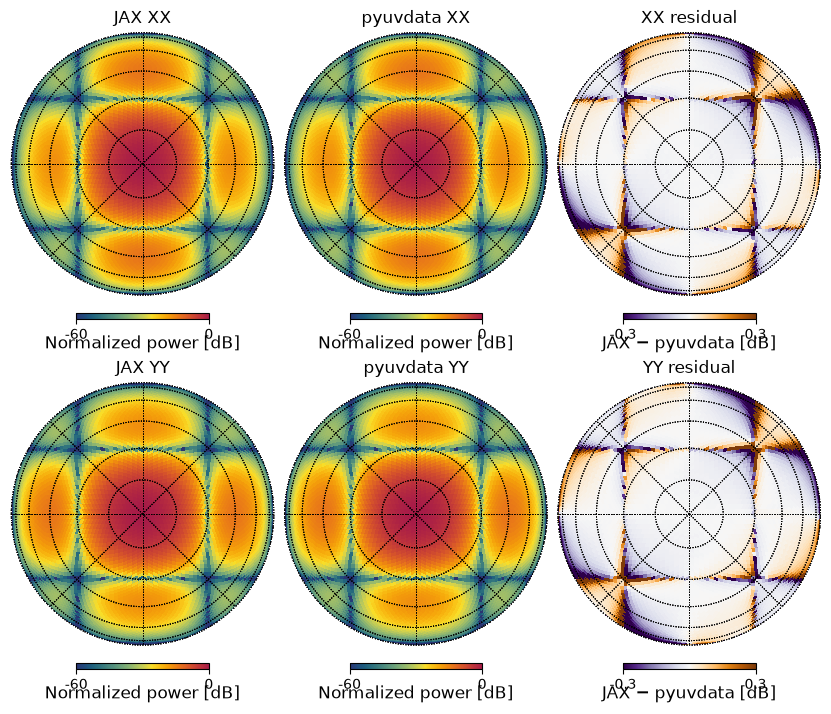

In [78]:
fig = plt.figure(
    figsize=(8.2, 7)
)

beam_kwargs = dict(
    rot=(0, 90, -90),
    half_sky=True,
    flip="geo",
    fig=fig,
    min=power_floor_db,
    max=0.0,
    unit="\n\nNormalized power [dB]",
    badcolor="whitesmoke",
    cmap=prd,
)

residual_kwargs = dict(
    rot=(0, 90, -90),
    half_sky=True,
    flip="geo",
    fig=fig,
    min=-0.3,
    max=0.3,
    unit="\n\nJAX − pyuvdata [dB]",
    cmap="PuOr_r",
)

hp.orthview(
    jax_maps[0],
    sub=(2, 3, 1),
    title="JAX XX",
    **beam_kwargs,
)

hp.orthview(
    jax_maps[1],
    sub=(2, 3, 4),
    title="JAX YY",
    **beam_kwargs,
)

hp.orthview(
    pyuv_maps[0],
    sub=(2, 3, 2),
    title="pyuvdata XX",
    **beam_kwargs,
)

hp.orthview(
    pyuv_maps[1],
    sub=(2, 3, 5),
    title="pyuvdata YY",
    **beam_kwargs,
)

hp.orthview(
    residual_maps[0],
    sub=(2, 3, 3),
    title="XX residual",
    **residual_kwargs,
)

hp.orthview(
    residual_maps[1],
    sub=(2, 3, 6),
    title="YY residual",
    **residual_kwargs,
)

for subplot in range(1, 7):
    hp.graticule(
        dpar=15,
        dmer=45,
        ls=":",
        lw=0.7,
        alpha=0.7,
    )

plt.show()

In [79]:
mask = (
    visible
    & (jax_power_db > -40)
    & (pyuv_power_db > -40)
)

for pol, name in enumerate(("XX", "YY")):
    r = residual_db[pol][mask[pol]]

    print(name)
    print(f"mean = {np.mean(r):+.4f} dB")
    print(f"std  = {np.std(r):.4f} dB")
    print(f"rms  = {np.sqrt(np.mean(r**2)):.4f} dB")
    print(f"max  = {np.max(np.abs(r)):.4f} dB")

XX
mean = -0.0080 dB
std  = 0.0563 dB
rms  = 0.0568 dB
max  = 0.2619 dB
YY
mean = -0.0082 dB
std  = 0.0563 dB
rms  = 0.0569 dB
max  = 0.2618 dB
